This notebook contains the code used to generate and explore word embeddings for each corpus.

In [2]:
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import collections
import re
import gensim

from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

In [3]:
ab = pd.read_csv('cleaned_text.csv')
op = pd.read_csv('cleaned_op_text.csv')
op['docket'] = op['docket'] + ' op'
print(ab.head())
print(op.head())

    docket                                               text
0  01-1118  catholic life sacrum mento support peti tioner...
1  88-1503  noc nan  beth cruzan parent coguardians lester...
2  18-1323  john  wilke barbara  wilke abortion question a...
3  89-1215  williams fire woman protect fetus reconciliati...
4   15-274  national medical organization combine membersh...
       docket                                               text
0  18-1323 op  note feasible headnote release do connection t...
1   88-805 op  ohio   akron center reproductive health united...
2  81-2338 op  regan secretary treasury   taxation representa...
3  88-1503 op  cruzan   director missouri dept health cruzan ...
4   88-605 op  webster attorney general missouri   reproducti...


Though ultimately not relevant to the current project, I found it useful to visualize the distribution of my documents across time.

In [3]:
with open("ab_dict.pkl", "rb") as f:
    ab_dict = pickle.load(f)
with open("op_dict.pikl", "rb") as f:
    op_dict = pickle.load(f)

## COME BACK TO THESE WHEN PERFECTING THE PROJECT NEXT QUARTER
common_dockets = set(op_dict.keys()) & set(ab_dict.keys())

# filter dictionaries to only keep common dockets
filtered_op_dict = {key: op_dict[key] for key in common_dockets}
filtered_ab_dict = {key: ab_dict[key] for key in common_dockets}

# print to check the number of common dockets
print(f"Number of common dockets: {len(common_dockets)}")

Number of common dockets: 39


### W2V Amicus Briefs ###

Default parameter model (**USED FOR ANALYSIS**):

In [33]:
tokenized_text = [word_tokenize(sentence) for sentence in ab["text"]]  # List of lists

# train and save the model
ab_w2v = Word2Vec(tokenized_text, vector_size=300, seed=42)
ab_w2v.save("ab_w2v.model")

vocab = ab_w2v.wv.index_to_key  # list of words in the vocabulary
print(vocab[:10])  # Print the first 10 words
print(len(vocab))

['abortion', 'religious', 'woman', 'child', 'state', 'life', 'right', 'decision', 'would', 'health']
3669


Model 2: utilizes a smaller vector size, a larger window, and a smaller min_count. You'll notice that the vocabulary size is larger than in the first model. This is because the lower min_count translates to more lenient criteria for inclusion in the model (a word only has to appear 3 times in the corpus to be included, rather than the default 5).

In [49]:
ab100 = Word2Vec(tokenized_text, vector_size=100, 
                 window=10, min_count=3, seed=42)

In [50]:
vocab = ab100.wv.index_to_key
print(len(vocab))

5340


In [82]:
sim = ab100.wv.most_similar('life', topn=5)
sim

[('human', 0.9969286322593689),
 ('unborn', 0.9948055744171143),
 ('conception', 0.9922143816947937),
 ('begin', 0.9919136762619019),
 ('sanctity', 0.9910510182380676)]

In [81]:
similar_words = ab_w2v.wv.most_similar("life", topn=5)
similar_words

[('human', 0.9954355955123901),
 ('unborn', 0.993111789226532),
 ('conception', 0.9901043176651001),
 ('begin', 0.9898290634155273),
 ('sanctity', 0.9891303777694702)]

Model 3: utilizes the same vector_size as the original model, but a larger window. This larger window likely lends itself to the *slightly* higher cosine similarities between the words (despite the topn similar words returned being exactly the same as the first model).

In [61]:
ab300 = Word2Vec(tokenized_text, vector_size=300, 
                 window=10, seed=42)

In [80]:
sim2 = ab300.wv.most_similar('life', topn=5)
sim2

[('human', 0.9983776211738586),
 ('unborn', 0.9970332384109497),
 ('conception', 0.9951561689376831),
 ('begin', 0.9951064586639404),
 ('sanctity', 0.9946063756942749)]

Exploring the embedding space of the amicus briefs when dimensions are reduced to 2 PCs:

Global PCA: [0.9734726  0.00993233]


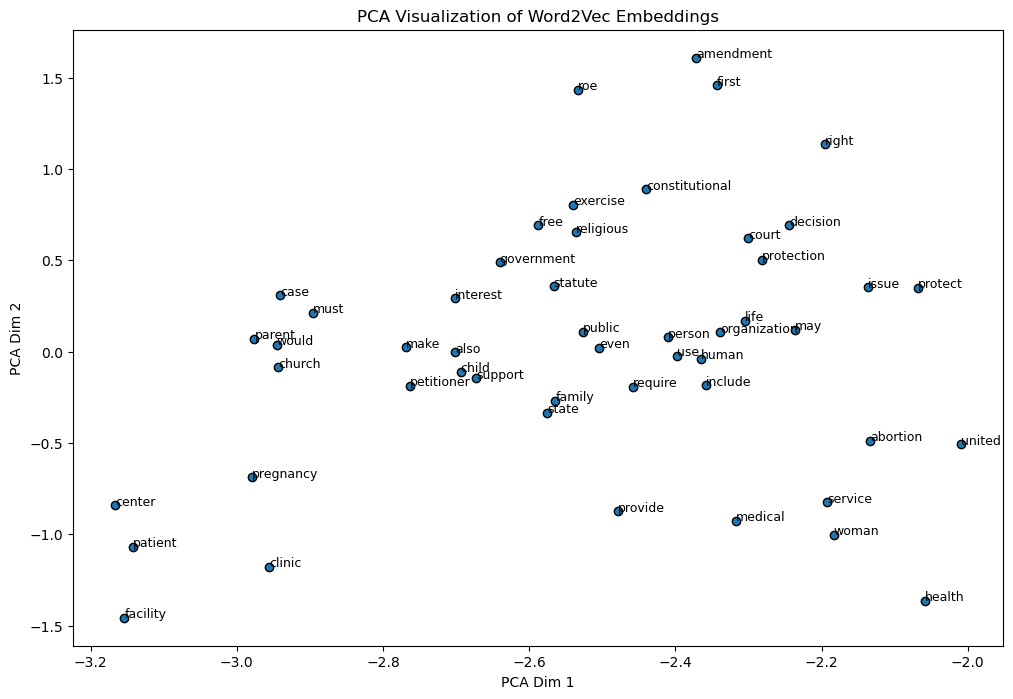

In [ ]:
word_vectors = ab_w2v.wv[ab_w2v.wv.index_to_key] # get word vectors from embedding model

pca = PCA(n_components=2, random_state=42)
word_vecs_2d_pca = pca.fit_transform(word_vectors)
print(f'Global PCA: {pca.explained_variance_ratio_}')

selected_words = vocab[:50]  # subset of words for viz purposes
selected_word_vecs = np.array([ab_w2v.wv[word] for word 
                               in selected_words])

# transform selected words using the pre-trained PCA
word_vecs_2d_pca = pca.transform(selected_word_vecs)

# plot
plt.figure(figsize=(12, 8))
plt.scatter(word_vecs_2d_pca[:, 0], word_vecs_2d_pca[:, 1], 
            edgecolors="k")

for i, word in enumerate(selected_words):
    plt.annotate(word, (word_vecs_2d_pca[i, 0], 
                        word_vecs_2d_pca[i, 1]), fontsize=9)

plt.title("PCA Visualization of Word2Vec Embeddings")
plt.xlabel("PCA Dim 1")
plt.ylabel("PCA Dim 2")
plt.show()
# this matters depending on how much of the variance these PCs are explaining

Interestingly, this graph shows more variation along the two PCs than one might expect: the first PC explains 97% of the variance, which means the overall shape of the corpus should be pretty linear. This is likely because the graph is a subset of the first 50 words in the vocabulary (not sorted by frequency). If I plotted the top 50 most frequent words, the distribution might appear more linear due to their clustering in high-density regions of the vector space.

### W2V Opinion ###
Follows the same process/logic as the amicus briefs (above). Because I wanted the corpora to be comparable, I utilized the same vector_size to maintain consistent dimensions between the embeddings (and ended up using the same default parameters after exploring others for the opinion corpus). Refer to the above section for more detail/insight into parameter tuning.

Default parameter model (**USED FOR ANALYSIS**)

In [100]:
op_tokenized_text = [word_tokenize(sentence) for sentence in op["text"]]  # List of lists
op_w2v = Word2Vec(op_tokenized_text, vector_size=300, seed=42)
op_w2v.save("op_w2v.model")

In [101]:
op_vocab = op_w2v.wv.index_to_key  # list of words in the vocabulary
print(op_vocab[:10])  
print(len(op_vocab))

['abortion', 'woman', 'state', 'would', 'health', 'may', 'decision', 'court', 'dissent', 'statute']
6712


In [94]:
op_sim_words = op_w2v.wv.most_similar("abortion", topn=5)
op_sim_words

[('seek', 0.9672839641571045),
 ('inform', 0.9618250131607056),
 ('necessary', 0.9548596143722534),
 ('obtain', 0.953982949256897),
 ('medically', 0.9524338245391846)]

Model 2: smaller vector_size, wider window, lower min_count. Min_count again yielded a larger vocab size than the default value.

In [89]:
op100 = Word2Vec(op_tokenized_text, vector_size=100, 
                 window=10, min_count=3, seed=42)
op100_vocab = op100.wv.index_to_key

print(len(op100_vocab))

9111


In [95]:
op100_sim_words = op100.wv.most_similar("abortion", topn=5)
op100_sim_words

[('pregnant', 0.9616156816482544),
 ('woman', 0.9400452375411987),
 ('procure', 0.9347904920578003),
 ('amniocentesis', 0.9331968426704407),
 ('risk', 0.9322397112846375)]

Model 3: same vector_size as default model, larger window. The larger window size produced lower cosine similarity scores, because although it is casting a wider contextual net, the words are still as far from one another in space as they are in the default embedding. This allows the model to identify words that are related to abortion, but that aren't exactly synonymous with it in the way the results for the default model were.

In [91]:
op300 = Word2Vec(op_tokenized_text, vector_size=300, 
                 window=10, seed=42)

In [96]:
op300_vocab = op300.wv.index_to_key  

op300_sim_words = op300.wv.most_similar("abortion", topn=5)
op300_sim_words

[('woman', 0.9551889300346375),
 ('pregnant', 0.9548404216766357),
 ('inform', 0.943220853805542),
 ('consent', 0.9271976947784424),
 ('pregnancy', 0.9218372106552124)]

There is greater variety in the words returned across these models than there was for the amicus briefs, along with generally lower cosine similarity scores. This is the product of the larger vocabulary size for this corpus, coupled with the wider window.

Exploring the embedding space of the opnions when dimensions are reduced to 2 PCs:

Global PCA: [0.55136997 0.15946153]


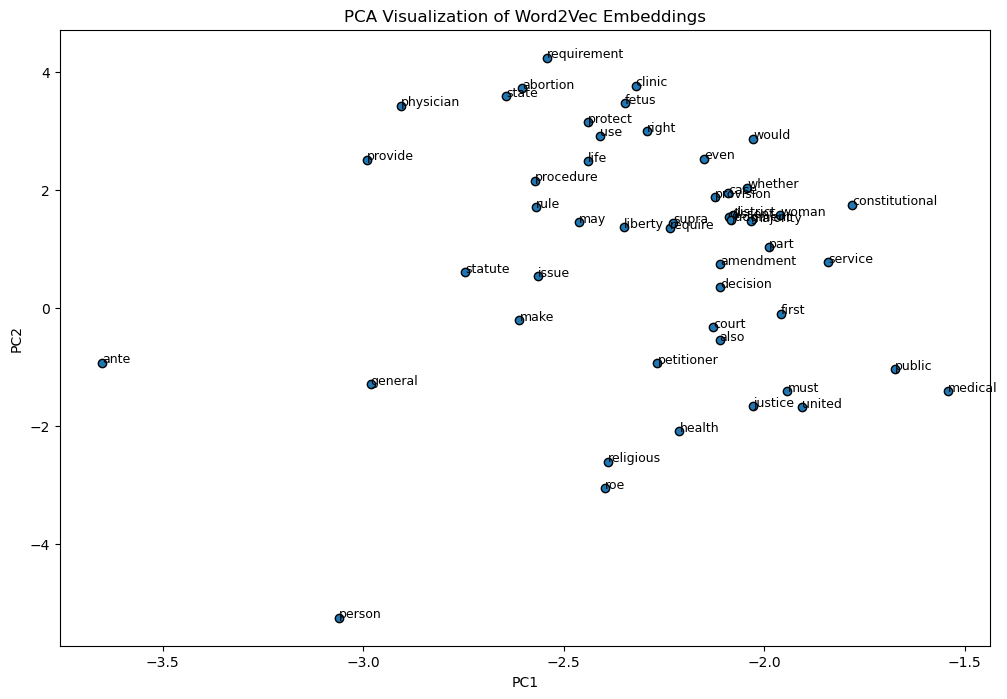

In [ ]:
op_word_vecs = np.array([op_w2v.wv[word] for word in op_vocab])

op_pca = PCA(n_components=2, random_state=42)
op_word_vecs_2d_pca = op_pca.fit_transform(op_word_vecs)
print(f'Global PCA: {op_pca.explained_variance_ratio_}')

op_selected_words = op_vocab[:50]
op_selected_word_vecs = np.array([op_w2v.wv[word] for word in selected_words])

op_word_vecs_2d_pca = op_pca.transform(op_selected_word_vecs)

plt.figure(figsize=(12, 8))
plt.scatter(op_word_vecs_2d_pca[:, 0], op_word_vecs_2d_pca[:, 1], edgecolors="k")

for i, word in enumerate(op_selected_words):
    plt.annotate(word, (op_word_vecs_2d_pca[i, 0], op_word_vecs_2d_pca[i, 1]), fontsize=9)

plt.title("PCA Visualization of Word2Vec Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Here, the PC1 explains 55% of the variance, meaning the overall structure should still largely align with PC1. Words related to healthcare ('clinic,' 'physician') and legal concepts ('statute,' 'justice') appear in distinct regions, reflecting potential topic divisions in the corpus. If we included more PCs, additional patterns might emerge, but this 2D visualization highlights the dominant relationships between terms.